# 09_3 — The lookahead in the anchor (the real reason the edge was fake)

The pump condition (+5%/15m AND vol>3x) is true at MANY consecutive minutes.
The notebook dedup anchored each event at the minute with the **max 15-min
return** — but you can only know which minute that is AFTER the cluster ends.
That is a forward-looking selection: it picks ≈ the top in hindsight.

A real bot enters at the **first** trigger. From there the pump keeps running
+2.74% on average before it tops — so shorting the first signal LOSES.

Data: 2025, clusters of triggers, three entry anchors compared (3% stop, 4h).

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

d = np.load('_out/entry_point_2025.npz')
pf, pm, pp, gap, drawup = d['pf'], d['pm'], d['pp'], d['gap'], d['drawup']
print(f'events: {len(pf)}')
for name, p in [('FIRST trigger (realistic bot)', pf),
                ('MAX-RET trigger (notebook anchor)', pm),
                ('ACTUAL PEAK (oracle, impossible)', pp)]:
    print(f'  {name:<34} mean {p.mean()*100:+.2f}%   win {(p>0).mean()*100:.0f}%')
print(f'  minutes first-trigger -> local peak: mean {gap.mean():.1f}, median {np.median(gap):.0f}')
print(f'  further run-up after first signal:   mean {drawup.mean()*100:+.2f}%')

events: 2180
  FIRST trigger (realistic bot)      mean -0.53%   win 37%
  MAX-RET trigger (notebook anchor)  mean +1.67%   win 57%
  ACTUAL PEAK (oracle, impossible)   mean +2.25%   win 63%
  minutes first-trigger -> local peak: mean 10.7, median 6
  further run-up after first signal:   mean +2.74%


[saved] notebooks\pump\_out\09_3_entry_point.png


WindowsPath('C:/projects/researchlab/notebooks/pump/_out/09_3_entry_point.png')

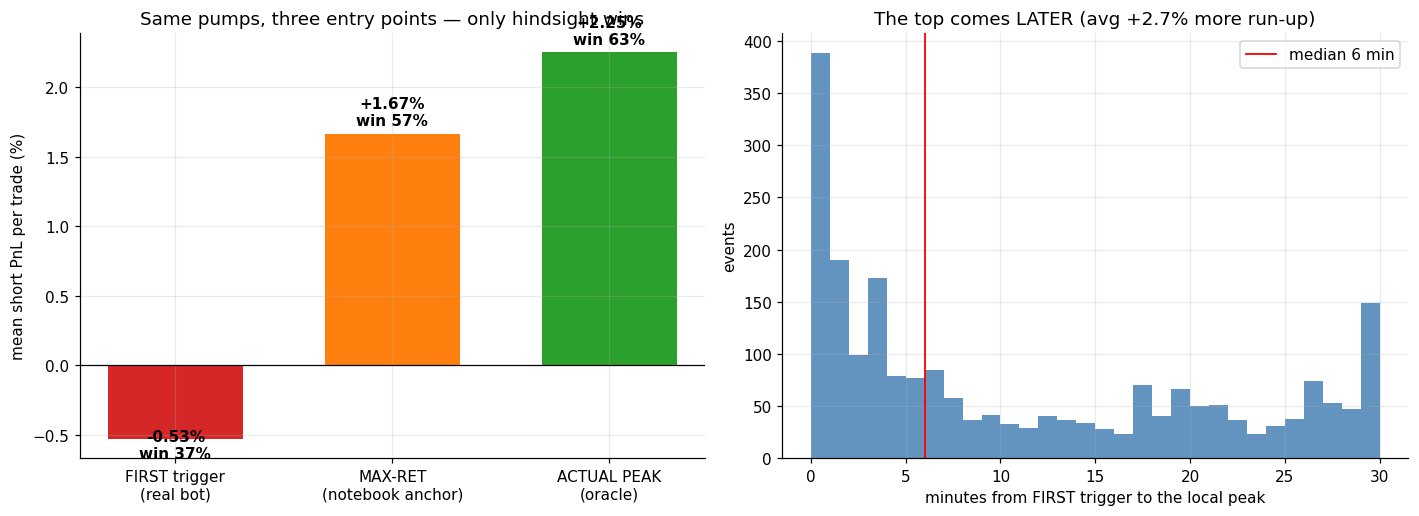

In [2]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8))
labels = ['FIRST trigger\n(real bot)', 'MAX-RET\n(notebook anchor)', 'ACTUAL PEAK\n(oracle)']
vals = [pf.mean()*100, pm.mean()*100, pp.mean()*100]
wins = [(pf>0).mean()*100, (pm>0).mean()*100, (pp>0).mean()*100]
colors = ['tab:red', 'tab:orange', 'tab:green']
bars = a1.bar(labels, vals, color=colors, width=0.62)
a1.axhline(0, color='k', lw=0.8)
for b, v, w in zip(bars, vals, wins):
    a1.text(b.get_x()+b.get_width()/2, v + (0.06 if v>=0 else -0.14),
            f'{v:+.2f}%\nwin {w:.0f}%', ha='center', fontsize=10, fontweight='bold')
a1.set_ylabel('mean short PnL per trade (%)')
a1.set_title('Same pumps, three entry points — only hindsight wins')

a2.hist(np.clip(gap, 0, 30), bins=np.arange(0, 31, 1), color='steelblue', alpha=0.85)
a2.axvline(np.median(gap), color='red', lw=1.2, label=f'median {np.median(gap):.0f} min')
a2.set_xlabel('minutes from FIRST trigger to the local peak')
a2.set_ylabel('events')
a2.set_title(f'The top comes LATER (avg +{drawup.mean()*100:.1f}% more run-up)')
a2.legend()
show('09_3_entry_point')